# 02 — Preprocess and describe the cohort

Filter genera once using the full retained cohort, preserve all metadata, and create exploratory PCA/t-SNE figures.

PCA and t-SNE are descriptive only. TEMPTED and MEFISTO perform their own method-specific transformations later.

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from skbio.stats.composition import closure, clr, multi_replace
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# preprocessing settings
PREVALENCE = 0.10
MIN_RA = 0.01
SEED = 2026

root = Path(".") if Path("data").exists() else Path("..")
source = sorted((root / "data" / "processed_16s").iterdir())[-1]
output = root / "data" / "preprocessing" / datetime.now().strftime("%Y%m%d_%H%M%S")
figures = output / "figures"
figures.mkdir(parents=True)

# load outputs from notebook 01
counts = pd.read_csv(source / "counts.csv", dtype={"sample_id": str}).set_index("sample_id")
metadata = pd.read_csv(source / "metadata.csv", dtype={"sample_id": str, "subject_id": str})
taxonomy = pd.read_csv(source / "taxonomy.csv")

## compositional preprocessing

`closure()`       converts each sample to proportions that sum to 1. 
`multi_replace()` performs scikit-bio's standard replacement for zeros
`clr()`           performs the centered log-ratio transform.

These transformations are used only PCA and t-SNE in this notebook.

**scikit-bio composition documentation:**  
https://scikit.bio/docs/latest/generated/skbio.stats.composition.html

**CLR:**  
https://scikit.bio/docs/latest/generated/skbio.stats.composition.clr.html

In [2]:
# filter genera by prevalence and relative abundance
relative = pd.DataFrame(
    closure(counts),
    index=counts.index,
    columns=counts.columns,
)

keep = (
    (counts.gt(0).mean() >= PREVALENCE)
    & (relative.ge(MIN_RA).mean() >= PREVALENCE)
)
counts = counts.loc[:, keep]
relative = relative.loc[:, keep]

# make clr data use in this notebook's plots
clr_data = clr(multi_replace(relative))

# pca and t-sne
pca = PCA(2).fit_transform(clr_data)
tsne = TSNE(
    2,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
).fit_transform(clr_data)

coords = metadata[["sample_id", "subject_id", "age", "country"]].copy()
coords[["pca_1", "pca_2"]] = pca
coords[["tsne_1", "tsne_2"]] = tsne

In [3]:
# prepare outputs
counts = counts.reset_index()  # row names to sample_id column

# save outputs
counts.to_csv(output / "counts_filtered.csv", index=False)
metadata.to_csv(output / "metadata.csv", index=False)
coords.to_csv(output / "coordinates.csv", index=False)

print("Retained", counts.shape[1] - 1, "genera")
print("Saved:", output)

Retained 31 genera
Saved: ../data/preprocessing/20260816_175250


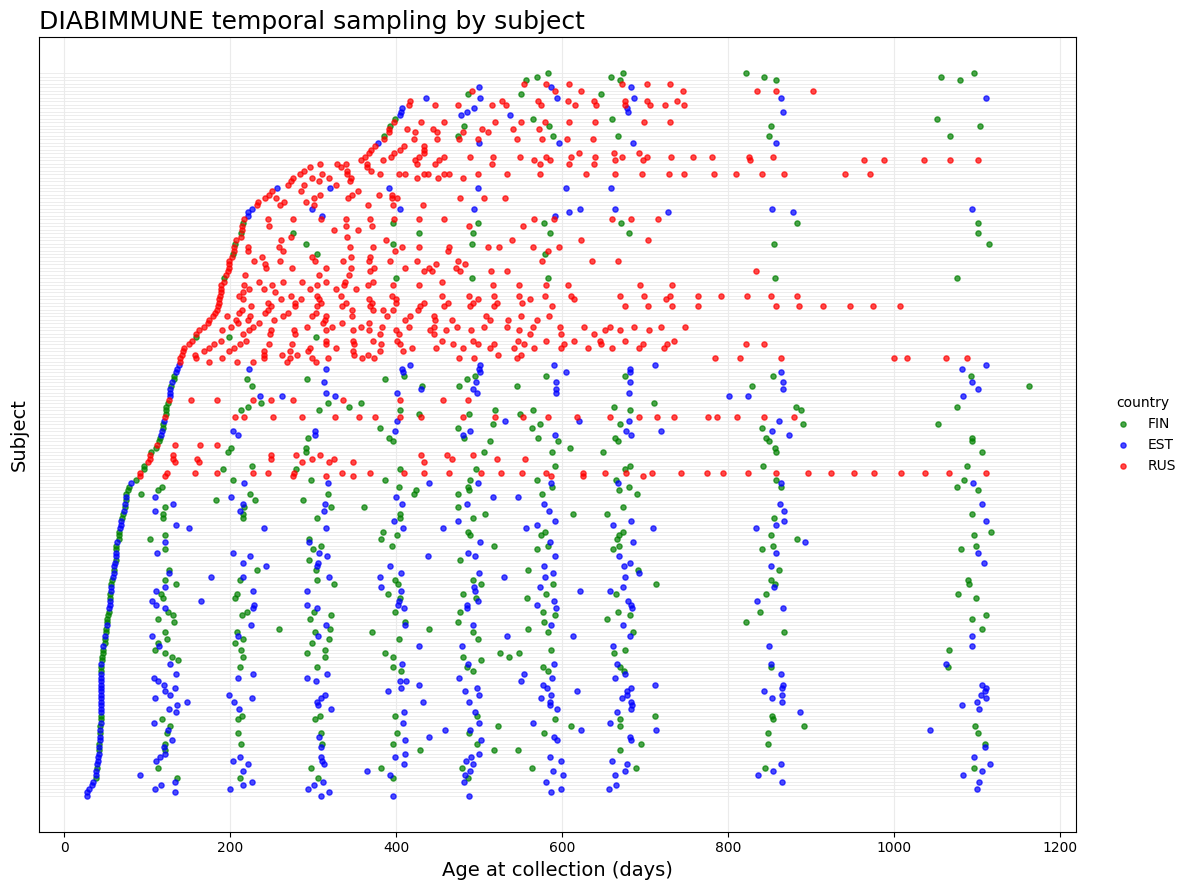

In [4]:
# temporal sampling schedule by subject
#
# Shows every retained sample at its collection age. Subjects are ordered
# primarily by their earliest retained collection age, producing a compact
# view of the cohort's irregular longitudinal sampling structure.

country_colors = {
    "FIN": "green",
    "EST": "blue",
    "RUS": "red",
}

sampling = metadata[
    ["sample_id", "subject_id", "age", "country"]
].copy()

sampling = sampling.dropna(
    subset=["subject_id", "age", "country"]
)

sampling["age"] = pd.to_numeric(
    sampling["age"],
    errors="coerce",
)
sampling = sampling.dropna(subset=["age"])

# Determine a stable subject order from each subject's sampling schedule.
# Earliest observation is the main ordering variable; later summaries break
# ties and keep subjects with similar schedules together.
subject_order = (
    sampling.groupby("subject_id")
    .agg(
        first_age=("age", "min"),
        mean_age=("age", "mean"),
        last_age=("age", "max"),
        n_samples=("age", "size"),
    )
    .sort_values(
        ["first_age", "mean_age", "last_age", "n_samples", "subject_id"],
        ascending=[True, True, True, False, True],
    )
    .index
    .tolist()
)

subject_y = {
    subject_id: i
    for i, subject_id in enumerate(subject_order)
}

sampling["subject_y"] = sampling["subject_id"].map(subject_y)

fig, ax = plt.subplots(figsize=(12, 9))

# faint horizontal line for every subject
for y in range(len(subject_order)):
    ax.axhline(
        y,
        color="0.90",
        linewidth=0.5,
        zorder=0,
    )

# one point per retained sample
for country in ["FIN", "EST", "RUS"]:
    rows = sampling["country"].eq(country)

    ax.scatter(
        sampling.loc[rows, "age"],
        sampling.loc[rows, "subject_y"],
        s=14,
        alpha=0.70,
        color=country_colors[country],
        label=country,
        zorder=2,
    )

ax.set_title(
    "DIABIMMUNE temporal sampling by subject",
    loc="left",
    fontsize=18,
)

ax.set_xlabel(
    "Age at collection (days)",
    fontsize=14,
)
ax.set_ylabel(
    "Subject",
    fontsize=14,
)

# Hundreds of subject labels would be unreadable, so retain the subject
# positions/grid while suppressing the text labels.
ax.set_yticks(range(len(subject_order)))
ax.set_yticklabels([])
ax.tick_params(axis="y", length=0)

ax.grid(
    axis="x",
    color="0.92",
    linewidth=0.8,
)

ax.legend(
    title="country",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)

plt.tight_layout()
plt.savefig(
    figures / "sampling_schedule.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()

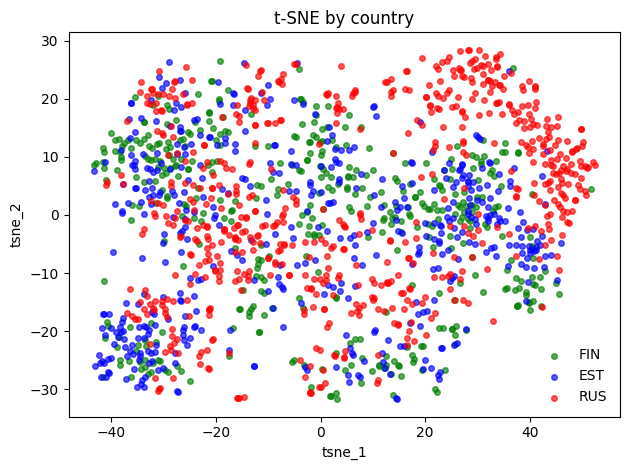

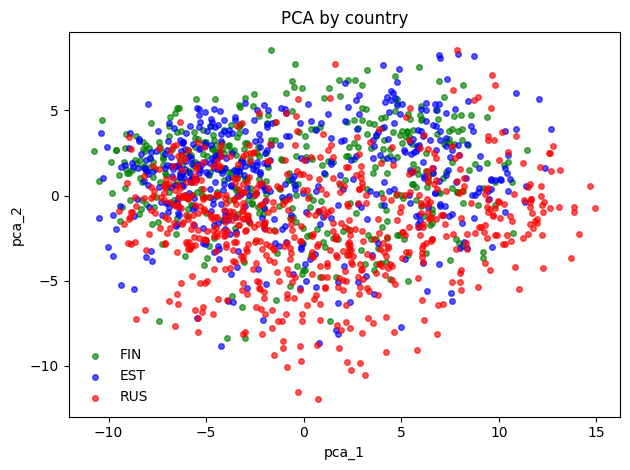

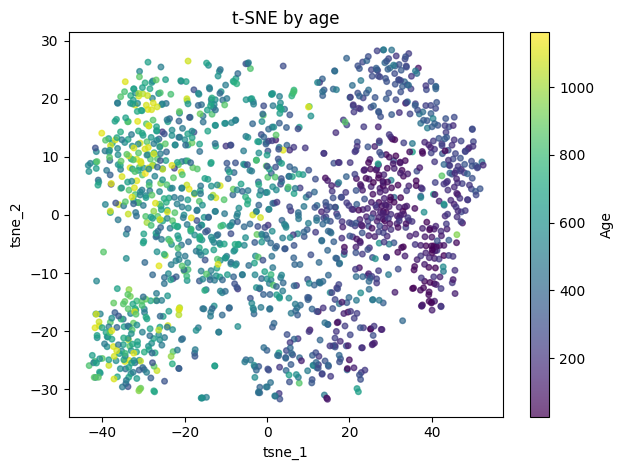

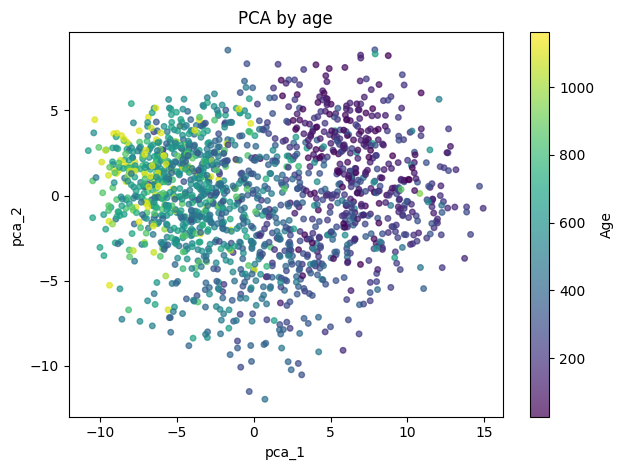

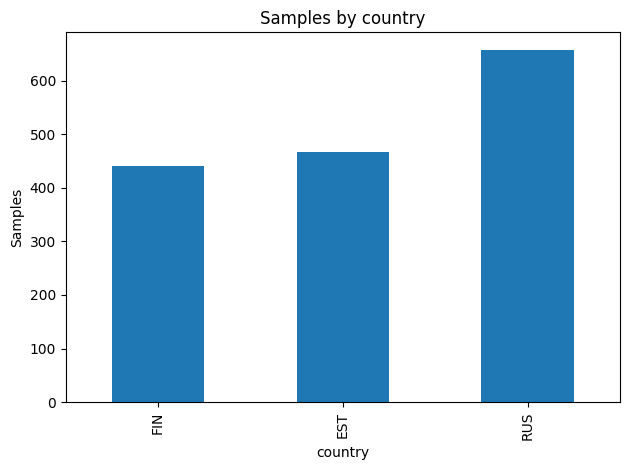

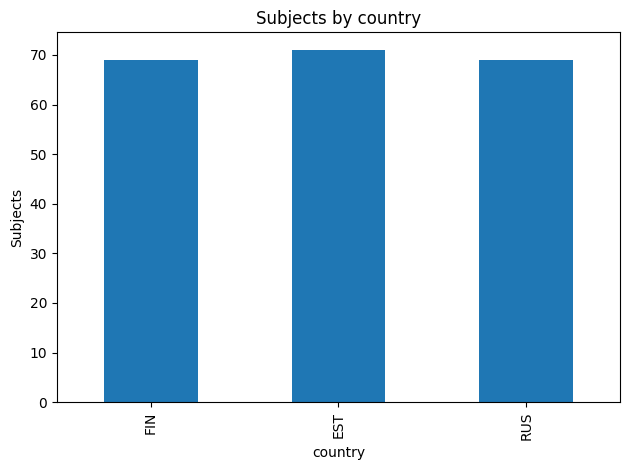

In [5]:
# save a figure

def save(name):
    plt.tight_layout()
    plt.savefig(figures / name, dpi=200)
    plt.show()
    plt.close()

countries = ["FIN", "EST", "RUS"]

colors = {
    "FIN": "green",
    "EST": "blue",
    "RUS": "red",
}

# plot ordinations by country

for x, y, name in [
    ("tsne_1", "tsne_2", "t-SNE"),
    ("pca_1", "pca_2", "PCA"),
]:
    for country in countries:
        rows = coords["country"] == country

        plt.scatter(
            coords.loc[rows, x],
            coords.loc[rows, y],
            s=16,
            alpha=.65,
            label=country,
            color=colors[country],
        )

    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend(frameon=False)
    plt.title(f"{name} by country")
    save(f"{name.lower()}_country.png")

# plot ordinations by age

for x, y, name in [
    ("tsne_1", "tsne_2", "t-SNE"),
    ("pca_1", "pca_2", "PCA"),
]:
    plt.scatter(
        coords[x],
        coords[y],
        c=coords["age"],
        s=16,
        alpha=.7,
        cmap="viridis",
    )

    plt.xlabel(x)
    plt.ylabel(y)
    plt.colorbar(label="Age")
    plt.title(f"{name} by age")
    save(f"{name.lower()}_age.png")

# show cohort size by country

metadata["country"].value_counts().reindex(countries).plot.bar()
plt.ylabel("Samples")
plt.title("Samples by country")
save("samples_by_country.png")

metadata.drop_duplicates("subject_id")["country"].value_counts().reindex(countries).plot.bar()
plt.ylabel("Subjects")
plt.title("Subjects by country")
save("subjects_by_country.png")